In [473]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn import preprocessing
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix, accuracy_score
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np


In [474]:
'''1.1 importing and describing the dataset'''

data_frame = pd.read_excel('Diabetes_Data.xlsx')
data_frame.describe()

matrix = data_frame.corr()
matrix

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


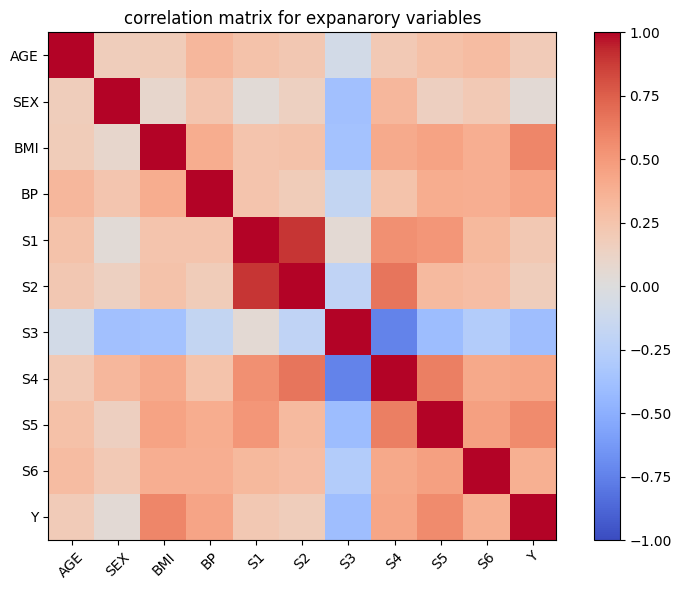

In [475]:
'''1.1 the correlation heatmap using imagesc and colorbar'''

plt.figure(figsize=(8,6))
image = plt.imshow(matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(image)

plt.xticks(range(len(matrix.columns)), matrix.columns, rotation = 45)
plt.yticks(range(len(matrix.columns)), matrix.columns)

plt.title('correlation matrix for expanarory variables')
plt.tight_layout()
plt.show()

In [476]:
#1.3. multivariate linear model


X = data_frame.drop(columns='Y')

#y = response variable
y = data_frame['Y']

X_const = sm.add_constant(X)

ols_model = sm.OLS(y, X_const).fit()

#predictions
y_pred = ols_model.predict(X_const)

# Mean Squared Error
mse = mean_squared_error(y, y_pred)

#adjusted R-squared
adj_r2 = ols_model.rsquared_adj

print("Mean Squared Error:", mse)
print("Adjusted R-squared:", adj_r2)

ols_model.summary()




Mean Squared Error: 2859.6963475867506
Adjusted R-squared: 0.5065592904853231


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        17:35:09   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -334.5671     67.455     -4.960      0.000    -467.148    -201.986
AGE           -0.0364      0.217     -0.168      0.867      -0.463       0.390
SEX          -22.8596      5.836     -3.917      0.000     -34.330     -11.389
BMI            5.6030      0.717      7.813      0.000       4.194       7.012
BP             1.1168      0.225      4.958      0.000       0.674       1.560
S1            -1.0900      0.573     -1.901      0.058      -2.217       0.037
S2             0.7465      0.531      1.406      0.160      -0.297       1.790
S3             0.3720      0.782      0.475      0.635      -1.166       1.910
S4             6.5338      5.959      1.097      0.273      -5.178      18.245
S5            68.4831     15.670      4.370      0.000      37.685      99.282
S6             0.2801      0.273      1.025      0.306      -0.257       0.817
==============================================================================
Omnibus:                        1.506   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.471   Jarque-Bera (JB):                1.404
Skew:                           0.017   Prob(JB):                        0.496
Kurtosis:                       2.726   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [477]:
'''1.5. using stepwise function to compose a model using forward selection '''

def forward_selection(X, y):
    remaining = list(X.columns)
    selected = []
    current_aic = sm.OLS(y, sm.add_constant(pd.DataFrame(index=X.index))).fit().aic

    while remaining:
        aic_with_candidates = []

        for candidate in remaining:
            X_candidate = sm.add_constant(X[selected + [candidate]])
            model = sm.OLS(y, X_candidate).fit()
            aic_with_candidates.append((model.aic, candidate))

        best_aic, best_candidate = min(aic_with_candidates)

        if best_aic < current_aic:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_aic = best_aic
        else:
            break

    return selected

selected_variables = forward_selection(X, y)
print("Selected variables:", selected_variables)

new_data_frame_variables = data_frame[ selected_variables]


#creating train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    new_data_frame_variables, y, test_size=0.3, random_state=101)

#creating a regression model
model = LinearRegression()

#fitting the model
model.fit(X_train, y_train)

#making predictions
predictions = model.predict(X_test)

#model evaluation
print('mean_squared_error : ', mean_squared_error(y_test, predictions))

#r2_score
r2 = r2_score(y_test, predictions)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted r2_score:", adj_r2)



Selected variables: ['BMI', 'S5', 'BP', 'S1', 'SEX', 'S2']
mean_squared_error :  3352.454863198959
Adjusted r2_score: 0.4339827338092851


In [478]:
'''2.2. finding probability of survival for a passenger in the titanic'''

titanic = pd.read_csv('titanic3.csv')
titanic.describe()



,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [479]:
survival_probability = titanic['survived'].mean()
print(f'survival_probability is: {survival_probability:.4f}')

survival_probability is: 0.3820


In [480]:
'''2.3. survival probability based on passenger class, gender and age '''

titanic_trimmed = titanic[['survived', 'pclass', 'sex', 'age']].dropna()

titanic_trimmed['age_group'] = pd.cut(
    titanic['age'],
    bins = [0,18,60,100],
    labels = ['child', 'adult', 'senior']
)

survival_table = (
    titanic_trimmed
    .groupby(['pclass','sex','age_group'])['survived']
    .mean()
    .reset_index()
)

survival_table



C:\Users\l\AppData\Local\Temp\ipykernel_16168\358966523.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['pclass','sex','age_group'])['survived']


,pclass,sex,age_group,survived
0,1,female,child,0.923077
1,1,female,adult,0.973684
2,1,female,senior,0.833333
3,1,male,child,0.750000
4,1,male,adult,0.359375
5,1,male,senior,0.066667
6,2,female,child,0.952381
7,2,female,adult,0.878049
8,2,female,senior,NaN
9,2,male,child,0.523810


In [481]:
#a logistic regression model for survival rates based on passenger class, sex and age

#selecting variables and drop missing values

titanic_model = titanic[['survived', 'pclass', 'sex', 'age']].dropna()

#encoding sex
titanic_model['sex'] = titanic_model['sex'].map({'male': 0, 'female': 1})

X = titanic_model[['pclass', 'sex', 'age']]
y = titanic_model['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

logistic_reg = LogisticRegression(max_iter=1000)


logistic_reg.fit(X_train, y_train)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [482]:
#parameter estimates
coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": logistic_reg.coef_[0]
})

intercept = logistic_reg.intercept_[0]

coef_table, intercept



(  Variable  Coefficient
 0   pclass    -0.974651
 1      sex     2.374089
 2      age    -0.030032,
 np.float64(1.7312557406840379))

In [483]:

X_sm = sm.add_constant(X)
logit_model = sm.Logit(y, X_sm).fit()

logit_model.summary()


Optimization terminated successfully.
         Current function value: 0.469897
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survived   No. Observations:                 1046
Model:                          Logit   Df Residuals:                     1042
Method:                           MLE   Df Model:                            3
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.3051
Time:                        17:35:10   Log-Likelihood:                -491.51
converged:                       True   LL-Null:                       -707.31
Covariance Type:            nonrobust   LLR p-value:                 3.167e-93
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0919      0.371      5.633      0.000       1.364       2.820
pclass        -1.1332      0.112    -10.142      0.000      -1.352      -0.914
sex            2.4974      0.166     15.033      0.000       2.172       2.823
age           -0.0339      0.006     -5.395      0.000      -0.046      -0.022
==============================================================================
"""

[*********************100%***********************]  30 of 30 completed


Explained variance ratio: [0.55651023 0.14336669]
PC1 shape: (30,)


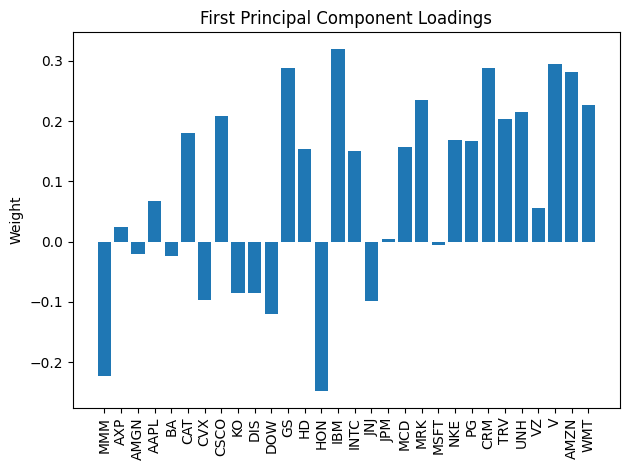

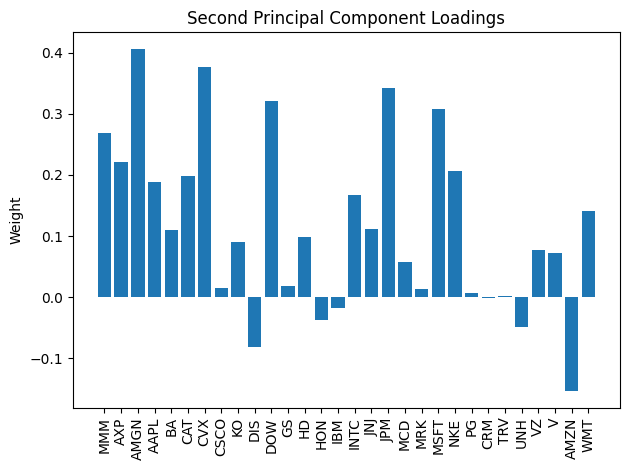

In [484]:
#3.3.
tickers = [
    'MMM','AXP','AMGN','AAPL','BA','CAT','CVX','CSCO','KO','DIS',
    'DOW','GS','HD','HON','IBM','INTC','JNJ','JPM','MCD','MRK',
    'MSFT','NKE','PG','CRM','TRV','UNH','VZ','V','AMZN','WMT'
]

#Downloading data
data = yf.download(
    tickers,
    start="2020-01-01",
    end="2021-01-01",
    interval="1d",
    group_by="ticker",
    auto_adjust=False
)

#Adjusted Close prices ONLY
adj_close = data.xs('Adj Close', axis=1, level=1)

#daily log returns
returns = np.log(adj_close / adj_close.shift(1)).dropna()

#Correlation matrix
corr_matrix = returns.corr()

#PCA on correlation matrix
pca = PCA(n_components=2)
pca.fit(corr_matrix)

pc1_weights = pca.components_[0]
pc2_weights = pca.components_[1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 shape:", pc1_weights.shape)

plt.figure()
plt.bar(tickers, pc1_weights)
plt.xticks(rotation=90)
plt.title("First Principal Component Loadings")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(tickers, pc2_weights)
plt.xticks(rotation=90)
plt.title("Second Principal Component Loadings")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


Variance explained by each component:
PC1: 0.5565
PC2: 0.1434

Cumulative variance explained:
PC1 to PC1: 0.5565
PC1 to PC2: 0.6999

Number of principal components required to explain 95% variance: 1


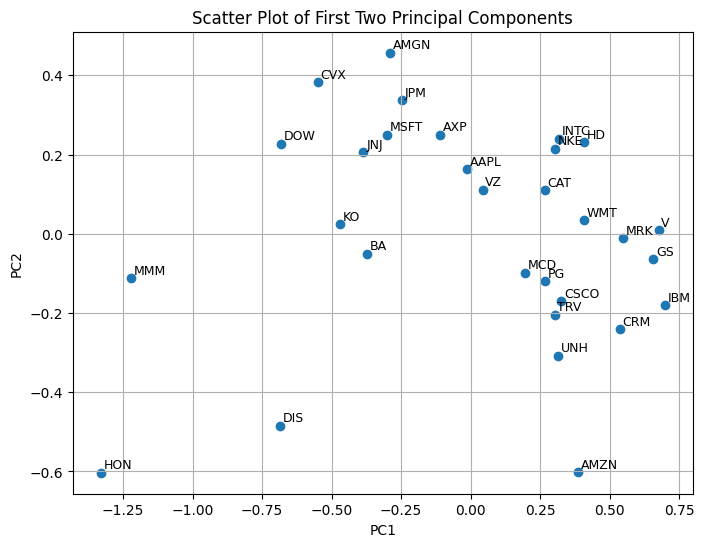

Centroid (average of PC1 & PC2): [2.07241631e-16 9.62193288e-17]
Three most distant (unusual) stocks: ['DIS', 'MMM', 'HON']


In [485]:
#3.4. amount of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print("Variance explained by each component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

#Cumulative variance
cumulative_variance = np.cumsum(explained_variance)
print("\nCumulative variance explained:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f}")

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of principal components required to explain 95% variance: {num_components_95}")

#3.5 scatter plot of the first two principal components and the average of all 30 stocks

pc_scores = pca.transform(corr_matrix)  # Shape: (30, 30)
#First two principal components
pc1 = pc_scores[:, 0]
pc2 = pc_scores[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(pc1, pc2)

for i, ticker in enumerate(tickers):
    plt.text(pc1[i]+0.01, pc2[i]+0.01, ticker, fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot of First Two Principal Components')
plt.grid(True)
plt.show()

#Average across all 30 stocks in PC space
centroid = np.mean(pc_scores[:, :2], axis=0)
print("Centroid (average of PC1 & PC2):", centroid)

#Euclidean distances
distances = np.sqrt((pc1 - centroid[0])**2 + (pc2 - centroid[1])**2)

#Find the three most distant stocks
most_distant_indices = np.argsort(distances)[-3:]
most_distant_stocks = [tickers[i] for i in most_distant_indices]
print("Three most distant (unusual) stocks:", most_distant_stocks)
